In [1]:
import torch
from transformers import BertForMaskedLM
from datasets import load_from_disk
import numpy as np
import os
import numpy as np
import matplotlib.pyplot as plt
from geneformer import TranscriptomeTokenizer
import pickle
import os
import anndata as ad
import scanpy as sc
import loompy
import pandas as pd
from collections import defaultdict

In [2]:
# Finding mappings from tokenizer gene to token id so for calculating attention weights

# Initialize the tokenizer
tokenizer = TranscriptomeTokenizer({'stimulation': 'stimulation'}, model_input_size=2048)


token_dict = tokenizer.gene_token_dict
print(f"Token dictionary contains {len(token_dict)} entries")

print("\nSample of token dictionary (first 10 entries):")
sample_items = list(token_dict.items())
for gene, token_id in sample_items:
    print(f"Gene: {gene}, Token ID: {token_id}")

# Create reverse mapping (token ID to gene)
token_to_gene = {}
for gene, token_id in token_dict.items():
    token_to_gene[token_id] = gene

# Print sample of reverse mapping
print("\nSample of token_to_gene mapping (first 10 entries):")
sample_items = list(token_to_gene.items())
for token_id, gene in sample_items:
    print(f"Token ID: {token_id}, Gene: {gene}")


Token dictionary contains 20275 entries

Sample of token dictionary (first 10 entries):
Gene: <pad>, Token ID: 0
Gene: <mask>, Token ID: 1
Gene: <cls>, Token ID: 2
Gene: <eos>, Token ID: 3
Gene: ENSG00000000003, Token ID: 4
Gene: ENSG00000000005, Token ID: 5
Gene: ENSG00000000419, Token ID: 6
Gene: ENSG00000000457, Token ID: 7
Gene: ENSG00000000460, Token ID: 8
Gene: ENSG00000000938, Token ID: 9
Gene: ENSG00000000971, Token ID: 10
Gene: ENSG00000001036, Token ID: 11
Gene: ENSG00000001084, Token ID: 12
Gene: ENSG00000001167, Token ID: 13
Gene: ENSG00000001460, Token ID: 14
Gene: ENSG00000001461, Token ID: 15
Gene: ENSG00000001497, Token ID: 16
Gene: ENSG00000001561, Token ID: 17
Gene: ENSG00000001617, Token ID: 18
Gene: ENSG00000001626, Token ID: 19
Gene: ENSG00000001629, Token ID: 20
Gene: ENSG00000001630, Token ID: 21
Gene: ENSG00000001631, Token ID: 22
Gene: ENSG00000002016, Token ID: 23
Gene: ENSG00000002330, Token ID: 24
Gene: ENSG00000002549, Token ID: 25
Gene: ENSG00000002586, To

In [3]:
# Saving cell States so we can map for attention weights
ds = loompy.connect("/u/scratch/r/ramadas/geneformer_tokenized_data/labeled_t_cell_data.loom")

# Extract the stimulation states for all cells
stimulation_states = ds.ca.stimulation
print(f"Extracted {len(stimulation_states)} cell classifications")
print(f"Sample values: {stimulation_states[:10]}")

# Convert to binary labels (assuming 'act' = 1, 'rest' = 0)
cell_labels = np.array([1 if state == 'act' else 0 for state in stimulation_states])
print(f"Sample Values: {cell_labels[:10]}")


Extracted 47726 cell classifications
Sample values: [np.str_('rest') np.str_('act') np.str_('rest') np.str_('rest')
 np.str_('rest') np.str_('act') np.str_('rest') np.str_('rest')
 np.str_('act') np.str_('rest')]
Sample Values: [0 1 0 0 0 1 0 0 1 0]


In [ ]:
model_directory = "/u/scratch/r/ramadas/geneformer_output/k5folds/250505142950/250505_geneformer_cellClassifier_cm_classifier_test/ksplit1/"
input_data_file = "/u/scratch/r/ramadas/geneformer_tokenized_data/Q_data_.dataset"
output_pickle_path = "/u/scratch/r/ramadas/geneformer_models_res/k5folds_47000.pkl"

model = BertForMaskedLM.from_pretrained(
    model_directory,
    output_hidden_states=True,
    output_attentions=True
)
model.eval()
model.to("cuda")
# load and select number of cells we want to evaluate 
dataset = load_from_disk(input_data_file)

max_cells = 1000
cell_attention_data = []
layer_to_extract = 5  

# Specify which layer's attention you want
for i in range(len(dataset)):
    example_cell = dataset.select([i])
    example_cell.set_format(type="torch")
    input_data = example_cell["input_ids"]

    cell_label = "Proliferating" if cell_labels[i] == 1 else "Quiescent"
    # Not updating model just evaluating 
    with torch.no_grad():
        outputs = model(input_ids=input_data.to("cuda"))
        
        if hasattr(outputs, 'attentions') and outputs.attentions is not None:
            # Extract the attention weights from the specified layer
            attn = outputs.attentions[layer_to_extract]

            # Map token IDs to gene names
            token_ids = input_data[0].cpu().numpy()
            gene_names = [token_to_gene.get(int(token_id), f"Unknown_{token_id}") for token_id in token_ids]
            
            cell_attention_data.append({
                'cell_idx': i,
                'label': cell_labels[i],
                'label_name': cell_label,
                'token_ids': token_ids,
                'gene_names': gene_names,
                'attention': attn.cpu().numpy()
            })
            
            print(f"Processed cell {i}, Label: {cell_label}") 

print(f"Saving attention weights..")
with open(output_pickle_path, 'wb') as f:
    pickle.dump(cell_attention_data, f, protocol=4)

print(f"Saved data to {output_pickle_path}")



Some weights of BertForMaskedLM were not initialized from the model checkpoint at /u/scratch/r/ramadas/geneformer_output/k5folds/250505142950/250505_geneformer_cellClassifier_cm_classifier_test/ksplit1/ and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading th

Processed cell 0, Label: Quiescent
Processed cell 1, Label: Proliferating
Processed cell 2, Label: Quiescent
Processed cell 3, Label: Quiescent
Processed cell 4, Label: Quiescent
Processed cell 5, Label: Proliferating
Processed cell 6, Label: Quiescent
Processed cell 7, Label: Quiescent
Processed cell 8, Label: Proliferating
Processed cell 9, Label: Quiescent
Processed cell 10, Label: Quiescent
Processed cell 11, Label: Quiescent
Processed cell 12, Label: Quiescent
Processed cell 13, Label: Quiescent
Processed cell 14, Label: Quiescent
Processed cell 15, Label: Quiescent
Processed cell 16, Label: Quiescent
Processed cell 17, Label: Quiescent
Processed cell 18, Label: Quiescent
Processed cell 19, Label: Quiescent
Processed cell 20, Label: Quiescent
Processed cell 21, Label: Quiescent
Processed cell 22, Label: Quiescent
Processed cell 23, Label: Quiescent
Processed cell 24, Label: Quiescent
Processed cell 25, Label: Quiescent
Processed cell 26, Label: Quiescent
Processed cell 27, Label: 

Number of cells in the saved data: 1000
Shape of first cell's attention weights: (1, 4, 2048, 2048)

Sample of attention weights from first cell, first head (10x10):
['0.0001', '0.0001', '0.0001', '0.0000', '0.0000', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0000', '0.0000', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0002', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0000', '0.0000', '0.0000', '0.0001', '0.0001', '0.0001', '0.0001']
['0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0001', '0.0002', '0.0001']
['0.0001', '0.0001', '0.00

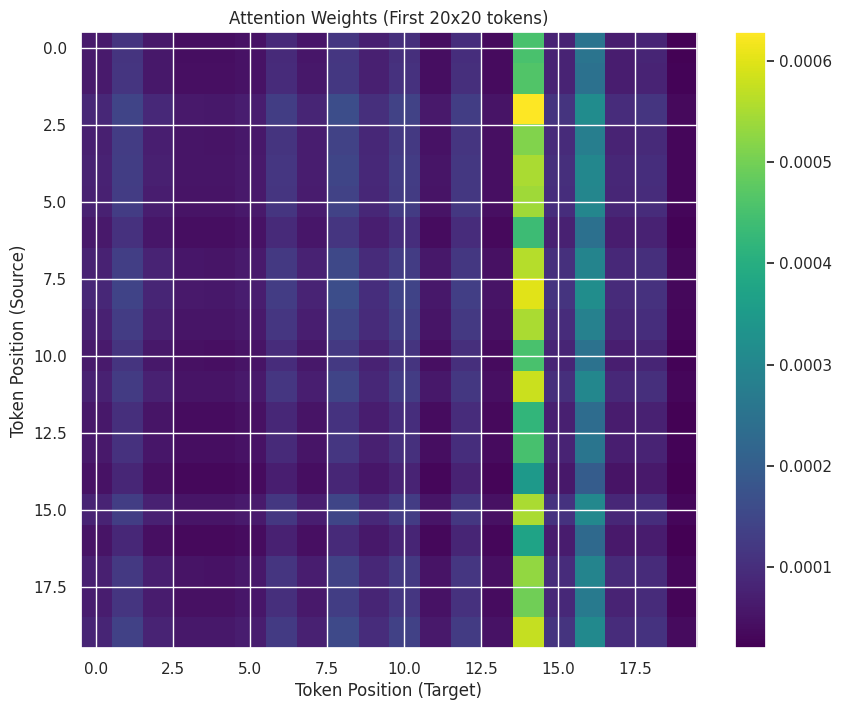

In [4]:

# Load the saved attention weights
attention_weights_path = "/u/scratch/r/ramadas/geneformer_models_res/k5folds_5000.pkl"
with open(attention_weights_path, 'rb') as f:
    attention_weights = pickle.load(f)


print(f"Number of cells in the saved data: {len(attention_weights)}")
print(f"Shape of first cell's attention weights: {attention_weights[0]['attention'].shape}")

# First cell attention data
first_cell_attn = attention_weights[0]['attention']
first_head = first_cell_attn[0, 0]  # [batch_size=0, head_idx=0]
sample_size = 10

print("\nSample of attention weights from first cell, first head (10x10):")
for i in range(sample_size):
    row = first_head[i, :sample_size]
    print([f"{val:.4f}" for val in row])

# Visualize attention pattern for a cell
plt.figure(figsize=(10, 8))
plt.imshow(first_head[:20, :20], cmap='viridis')
plt.colorbar()
plt.title("Attention Weights (First 20x20 tokens)")
plt.xlabel("Token Position (Target)")
plt.ylabel("Token Position (Source)")
print("\nSaved visualization to attention_heatmap.png")

In [9]:
# Take Attention Weight Matrix and sum down gene returning genes recieving greatest attention per cell

# Two ways to do it summing and also cls(which is used for classification)
def rank_genes_by_attention(cell_attention_data, method="sum", num_top_genes=50):
    cell_rankings = []
    
    # Saving by gene type so we can later generalize based on these
    quiescent_genes = defaultdict(list)
    proliferating_genes = defaultdict(list)
    all_genes = defaultdict(list)
    
    for index,cell_data in enumerate(cell_attention_data):
            gene_names = cell_data['gene_names']
            all_batch_attention = []
            for batch_idx in range(len(cell_data['attention'])):
                all_batch_attention.append(cell_data['attention'][batch_idx])
            attention = np.mean(all_batch_attention, axis=0) 
            label = cell_data['label_name']
            print(f'Cell {index}, {label}')

            avg_attention = np.mean(attention, axis = 0)

            # Calculate gene importance
            if method == "cls":
                # CLS token is at position 0 - how much it attends to each gene
                gene_importance = avg_attention[0]
            else: 
                # Sum attention down columns (how much attention each gene receives)
                gene_importance = np.sum(avg_attention, axis=0)

            if label == "Quiescent":
                gene_dict = quiescent_genes
            elif label == "Proliferating":
                gene_dict = proliferating_genes

            cell_gene_scores = {}

            # Now map these summed weights to the gene name by indexing
            for i, gene in enumerate(gene_names):
                score = float(gene_importance[i])
                cell_gene_scores[gene] = score


                #Now aggregating to those cell dictionaries 
                gene_dict[gene].append(score)
                all_genes[gene].append(score)

            # Ranking genes within each cell by attention weights
            ranked_genes = sorted(cell_gene_scores.items(), key=lambda x: x[1], reverse=True)
            for gene, score in ranked_genes[:10]:
                print(f'Gene: {gene}, Score: {score}')

            # Saving in Cell Rankings so we can compare across them 
            cell_df = pd.DataFrame(ranked_genes[:num_top_genes], columns=['Gene', 'Attention Score'])
            cell_rankings.append({
                'cell_id': index,
                'label': label,
                'rankings': cell_df,
                'top_genes': [gene for gene, _ in ranked_genes[:10]]  # Store top 10 genes for quick comparison
            })
    return cell_rankings

                
                

    
run = rank_genes_by_attention(attention_weights, method="sum")

output_file = "/u/scratch/r/ramadas/geneformer_models_res/gene_rankings5000.pkl"
with open(output_file, 'wb') as f:
          pickle.dump(run,f)
print(f"Results saved to {output_file}")


Cell 0, Quiescent
Gene: ENSG00000104964, Score: 7.6149091720581055
Gene: ENSG00000005007, Score: 6.423831939697266
Gene: ENSG00000143612, Score: 6.361800193786621
Gene: ENSG00000100401, Score: 6.348027229309082
Gene: ENSG00000008988, Score: 6.039608478546143
Gene: ENSG00000165650, Score: 5.90291166305542
Gene: ENSG00000151023, Score: 5.655440330505371
Gene: ENSG00000115963, Score: 5.5942864418029785
Gene: ENSG00000112981, Score: 5.255273818969727
Gene: ENSG00000110057, Score: 5.242654323577881
Cell 1, Proliferating
Gene: ENSG00000165732, Score: 53.80866622924805
Gene: ENSG00000111640, Score: 33.136924743652344
Gene: ENSG00000169288, Score: 32.05924606323242
Gene: ENSG00000165650, Score: 31.518035888671875
Gene: ENSG00000143977, Score: 29.889785766601562
Gene: ENSG00000008394, Score: 29.331073760986328
Gene: ENSG00000152056, Score: 29.199886322021484
Gene: ENSG00000135269, Score: 28.509611129760742
Gene: ENSG00000143612, Score: 28.38368797302246
Gene: ENSG00000083312, Score: 27.18734550